In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from skimage import data
from skimage.metrics import peak_signal_noise_ratio as psnr, mean_squared_error as mse

from skimage.filters import gaussian, median

from skimage.morphology import footprint_rectangle

In [ ]:
def load_image(image_path):
    if os.path.exists(image_path):
        image = Image.open(image_path).convert('L')
        return np.asarray(image, dtype=np.float64)
    return np.asarray(data.camera(), dtype=np.float64)

# Dodavanje Gausovog šuma na sliku

Vezu između orginalne slike(u) i slike sa šumom(f) predstavljamo modelom:

    f = u + η
pri čemu je η šum koji se dodaje. Šum je slučajna vrednost iz Gausove(normalne) raspodele, odnosno iz raspodele sa srednjom vrednošću 0, a intenzitet šuma zavisi od izabrane standarne devijacije.

In [ ]:

def add_gaussian_noise(image, std_dev):
    noisy_image = image + np.random.normal(0.0, std_dev, image.shape)
    return np.clip(noisy_image, 0.0, 255.0)


# Gausov i Median filteri - konvolucija

U kontekstu slika, konvolucija predstavlja kompoziciju dveju matrica. Veća matrica je matrica piksela originalne slike, a manja matrica filter koji se primenjuje. Filter se pomera preko slika i za svaki piksel računa novu vrednost na osnovu:

    1. operacije koja je definisana
    2. okoline centralnog piksela - okolina je definisana veličinom filtera

Gausov filter:

    1. posmatra grupu priksela u okviru prozora definisanog veličinog matrice filtera MxM
    2. svakom pikselu u okviru prozora dodeljuje se težina i računa se ponderisana srednja vrednost
    3. vrednost centralnog piksela postavlja na izračunatu srednju vrednost

    Parametri:
    1. slika iz koje se elimiše šum
    2. sigma - širina Gausove raspodele, određuje koliki uticaj imaju bliži, odnosno udaljeniji pikseli
    3. preserve range - vrednosti ostaju u istom opsegu kao i originalna slika

Median filter:
    
    1. posmatra grupu priksela u okviru prozora definisanog veličinog matrice filtera MxM
    2. sortira posmatrane vrednosti
    3. vrednost centralnog piksela postavlja na medijanu sortiranog niza

    Parametri:
    1. slika iz koje se elimiše šum
    2. footprint - veličina matrice filtera

In [ ]:

def denoise_gaussian_filter(image, std_dev):
    return gaussian(image, sigma=std_dev, preserve_range=True)

def denoise_median_filter(image, size):
    return median(image, footprint=footprint_rectangle((size, size)))

In [41]:

def plot_orginal_and_noisy(original_image, noisy_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap='gray', vmin=0, vmax=255)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(noisy_image, cmap='gray', vmin=0, vmax=255)
    plt.title('Sa šumom')
    plt.axis('off')


def forward_gradient(u):
    gx = np.zeros_like(u)
    gy = np.zeros_like(u)
    gx[:, :-1] = u[:, 1:] - u[:, :-1]
    gy[:-1, :] = u[1:, :] - u[:-1, :]
    return gx, gy

def divergence(px, py):
    div = np.zeros_like(px)
    div[:, 0] = px[:, 0]
    div[:, 1:] = px[:, 1:] - px[:, :-1]
    div[0, :] += py[0, :]
    div[1:, :] += py[1:, :] - py[:-1, :]
    return div

def chambolle_projection(f, lam, dt=0.248, tol=1e-2, max_iter=5000, p=None):
    px = np.zeros_like(f) if p is None else p[0].copy()
    py = np.zeros_like(f) if p is None else p[1].copy()

    for _ in range(max_iter):
        gx, gy = forward_gradient(divergence(px, py) - f / lam)
        norm = np.sqrt(gx * gx + gy * gy)
        denom = 1.0 + dt * norm
        px_new = (px + dt * gx) / denom
        py_new = (py + dt * gy) / denom
        change = max(np.max(np.abs(px_new - px)), np.max(np.abs(py_new - py)))
        px, py = px_new, py_new
        if change <= tol:
            break

    u = np.clip(f - lam * divergence(px, py), 0.0, 255.0)
    return u, (px, py)

def denoise_tv(noisy_image, std_dev=20, n_outer=5, lam=None):
    sigma = std_dev
    n = np.sqrt(noisy_image.size)
    if lam is None:
        lam = 1.0 / (2.1237 / std_dev + 2.0547 / (std_dev ** 2))
    p = None
    u = noisy_image
    for _ in range(n_outer):
        u, p = chambolle_projection(noisy_image, lam, p=p)
        residual = np.linalg.norm(u - noisy_image)
        lam = lam * (n * sigma) / residual
    return u

In [42]:
def compare(*images):

    img_num = len(images) // 2

    plt.figure(figsize=(12, 3*img_num))

    for i in range(img_num):
        plt.subplot(img_num, 2, i + 1)
        plt.imshow(images[2*i], cmap='gray', vmin=0, vmax=255)
        plt.title(images[2*i + 1])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def plot_signal(*images):

    row = original_image.shape[0] // 2
    img_num = len(images) // 2

    plt.figure(figsize=(12, 3*img_num))

    for i in range(img_num):
        plt.subplot(img_num, 2, 2*i + 1)
        plt.imshow(images[2*i], cmap='gray', vmin=0, vmax=255)
        plt.title(images[2*i + 1])
        plt.axis('off')

        plt.subplot(img_num, 2, 2*i + 2)
        plt.plot(images[2*i][row, :], color='blue', linewidth=1.5)
        plt.title(images[2*i + 1])
        plt.grid(True, alpha=0.3)
        plt.ylim([0, 255])

    plt.tight_layout()
    plt.show()

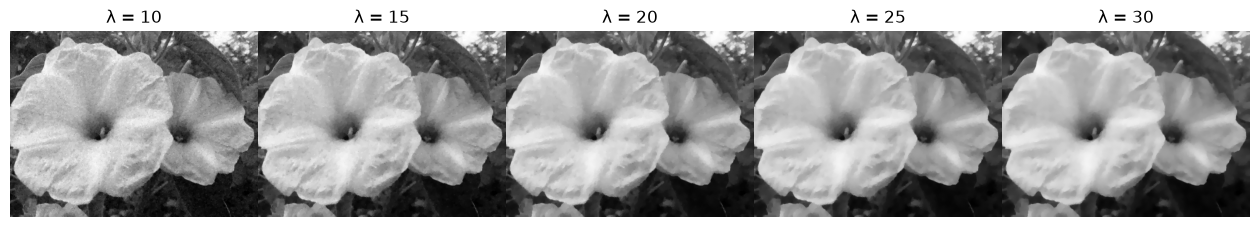

In [34]:
# Kako se Chambolle TV ponaša za različite lambda vrednosti:

original_image = load_image('flowers.jpg')
noisy_image = add_gaussian_noise(original_image, 20)

diff_lambda_values = [10, 15, 20, 25, 30]
tv_denoised_images = []
for value in diff_lambda_values:
    u, _ = chambolle_projection(noisy_image, value)
    tv_denoised_images.append(u)

fig, axes = plt.subplots(
    1, len(tv_denoised_images),
    figsize=(16, 10)
)

for ax, image, value in zip(axes, tv_denoised_images, diff_lambda_values):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'λ = {value}')
    ax.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

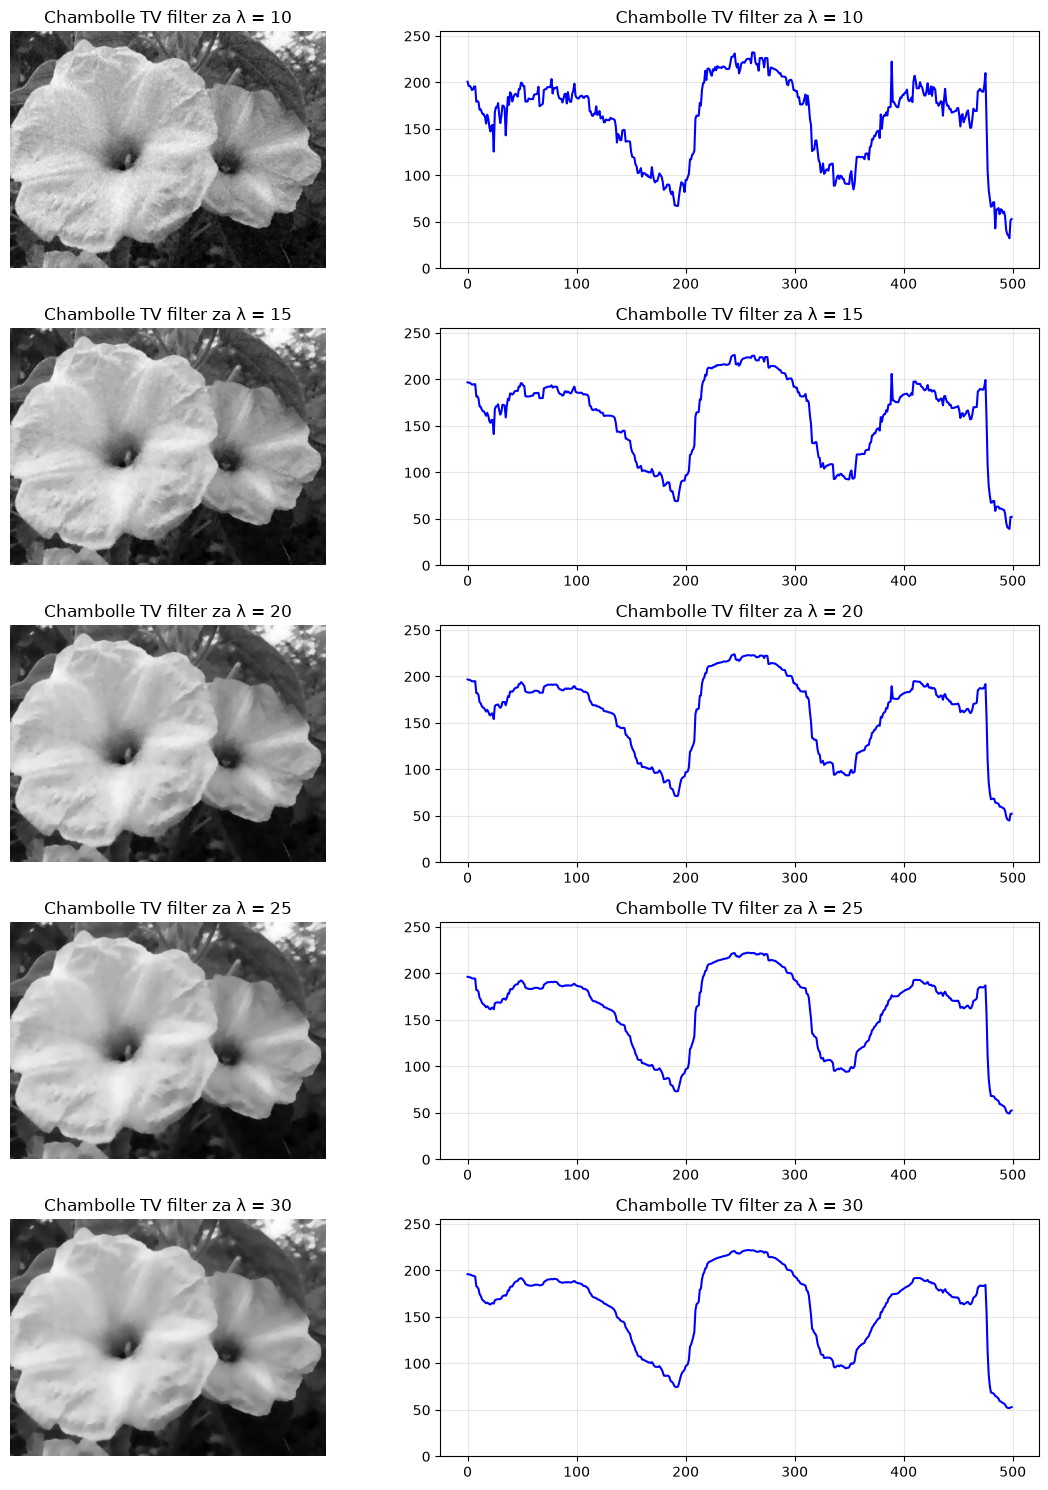

In [35]:
plot_signal(tv_denoised_images[0], 'Chambolle TV filter za λ = 10',\
            tv_denoised_images[1], 'Chambolle TV filter za λ = 15',\
            tv_denoised_images[2], 'Chambolle TV filter za λ = 20',\
            tv_denoised_images[3], 'Chambolle TV filter za λ = 25',\
            tv_denoised_images[4], 'Chambolle TV filter za λ = 30')

In [36]:
# Kako različiti algoritmi reaguju na povećanje intenziteta šuma

std_var = [10, 20, 30, 40, 50]

noisy_images = []
gaussian_denoised_images = []
median_denoised_images = []
tv_denoised_images = []

original_image = load_image('flowers.jpg')

for i, std in enumerate(std_var):

    noisy_images.append(add_gaussian_noise(original_image, std))
    
    gaussian_denoised_images.append(denoise_gaussian_filter(noisy_images[i], 0.5))
    
    median_denoised_images.append(denoise_median_filter(noisy_images[i], 3))

    tv_denoised_images.append(denoise_tv(noisy_images[i], 20))
    
    #plot_orginal_and_noisy(original_image, noisy_images[i])

In [37]:

psnr_gaussian = [round(psnr(original_image, gaussian_denoised, data_range=255), 2) for gaussian_denoised in gaussian_denoised_images]
psnr_median = [round(psnr(original_image, median_denoised, data_range=255), 2) for median_denoised in median_denoised_images]
psnr_tv = [round(psnr(original_image, tv_denoised, data_range=255), 2) for tv_denoised in tv_denoised_images]

mse_gaussian = [mse(original_image, gaussian_denoised) for gaussian_denoised in gaussian_denoised_images]
mse_median = [mse(original_image, median_denoised) for median_denoised in median_denoised_images]
mse_tv = [mse(original_image, tv_denoised) for tv_denoised in tv_denoised_images]

data = {
    "Intenzitet šuma": std_var,
    "PSNR Gaussian": [str(psnr_gaussian_) + " dB" for psnr_gaussian_ in psnr_gaussian],
    "PSNR Median": [str(psnr_median_) + " dB" for psnr_median_ in psnr_median],
    "PSNR Chambolle TV": [str(psnr_tv_) + " dB" for psnr_tv_ in psnr_tv],
    "MSE Gaussian": mse_gaussian,
    "MSE Median": mse_median,
    "MSE Chambolle TV": mse_tv
}


df = pd.DataFrame(data)
df

,Intenzitet šuma,PSNR Gaussian,PSNR Median,PSNR Chambolle TV,MSE Gaussian,MSE Median,MSE Chambolle TV
0,10,31.79 dB,33.63 dB,26.84 dB,43.033496,28.171756,134.662687
1,20,26.01 dB,29.04 dB,31.7 dB,162.774996,81.073321,43.979128
2,30,22.65 dB,25.94 dB,26.21 dB,353.130290,165.795322,155.783904
3,40,20.38 dB,23.64 dB,21.67 dB,596.369003,281.436938,443.001512
4,50,18.69 dB,21.83 dB,18.86 dB,878.580357,426.959725,845.522175


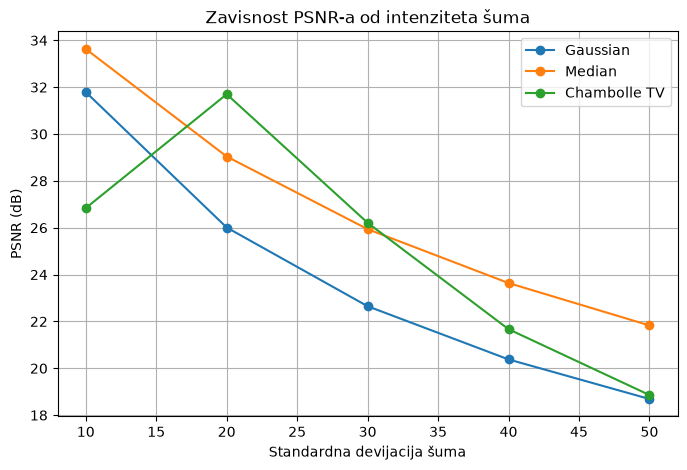

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(std_var, psnr_gaussian, marker='o', label='Gaussian')
plt.plot(std_var, psnr_median, marker='o', label='Median')
plt.plot(std_var, psnr_tv, marker='o', label='Chambolle TV')

plt.xlabel('Standardna devijacija šuma')
plt.ylabel('PSNR (dB)')
plt.title('Zavisnost PSNR-a od intenziteta šuma')

plt.legend()
plt.grid(True)
plt.show()